# 02 - Training: Animal Classifier (MobileNetV2 transfer learning)

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt

from src.data_loader import get_datasets
from src.model import build_model

DATA_DIR = "../data/raw/animals10/raw-img"

In [2]:
train_ds, val_ds, class_names = get_datasets(DATA_DIR)
print(class_names)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


**Note:** copy the printed `class_names` order into `app/app.py`'s `CLASS_NAMES` list — the model output indices must match this order.

In [3]:
model = build_model(num_classes=len(class_names))
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train (frozen base)

In [4]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 356s 408ms/step - accuracy: 0.8607 - loss: 0.4382 - val_accuracy: 0.9408 - val_loss: 0.1982
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 236s 360ms/step - accuracy: 0.9101 - loss: 0.2872 - val_accuracy: 0.9475 - val_loss: 0.1831
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 191s 291ms/step - accuracy: 0.9196 - loss: 0.2562 - val_accuracy: 0.9540 - val_loss: 0.1620
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 191s 292ms/step - accuracy: 0.9205 - loss: 0.2586 - val_accuracy: 0.9564 - val_loss: 0.1584
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 191s 292ms/step - accuracy: 0.9237 - loss: 0.2397 - val_accuracy: 0.9528 - val_loss: 0.1691
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 197s 301ms/step - accuracy: 0.9260 - loss: 0.2405 - val_accuracy: 0.9540 - val_loss: 0.1650
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 195s 298ms/step - accuracy: 0.9250 - loss: 0.2356 - val_accuracy: 0.9543 - val_loss: 0.1646
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 207s 316ms/step - accuracy: 0.9268 -

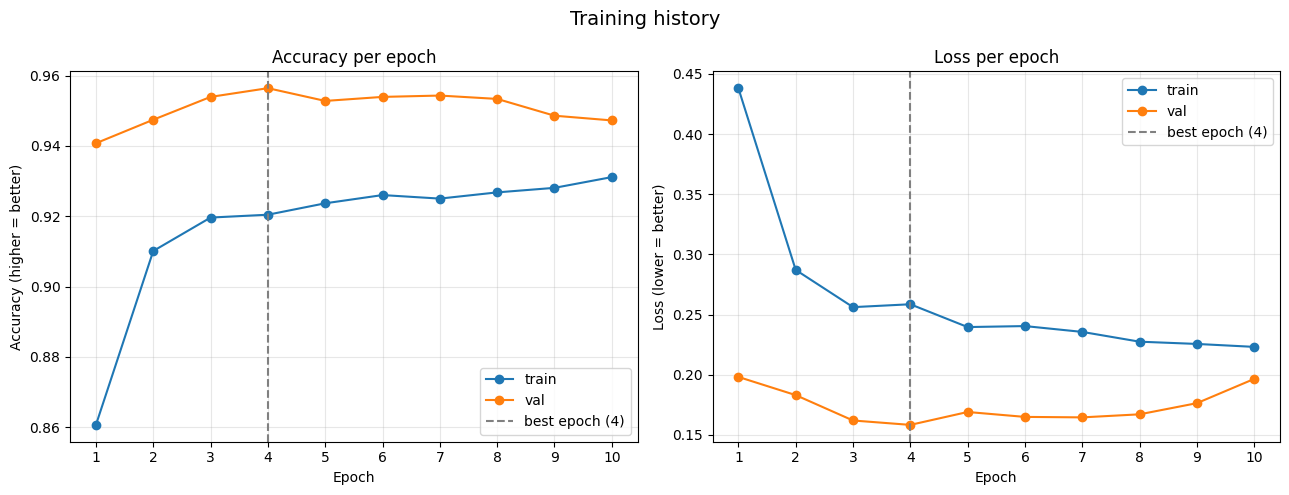

Best epoch: 4 (val_loss=0.1584, val_accuracy=0.9564)
Last epoch: 10 (val_loss=0.1966, val_accuracy=0.9473)
-> val_loss went back up after the best epoch: model started overfitting past that point.


In [6]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)
best_epoch = val_loss.index(min(val_loss)) + 1  # epoch with lowest val_loss = best checkpoint

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, acc, "o-", label="train")
axes[0].plot(epochs_range, val_acc, "o-", label="val")
axes[0].axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch ({best_epoch})")
axes[0].set_title("Accuracy per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (higher = better)")
axes[0].set_xticks(epochs_range)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_range, loss, "o-", label="train")
axes[1].plot(epochs_range, val_loss, "o-", label="val")
axes[1].axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch ({best_epoch})")
axes[1].set_title("Loss per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (lower = better)")
axes[1].set_xticks(epochs_range)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle("Training history", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Best epoch: {best_epoch} (val_loss={val_loss[best_epoch-1]:.4f}, val_accuracy={val_acc[best_epoch-1]:.4f})")
print(f"Last epoch: {len(acc)} (val_loss={val_loss[-1]:.4f}, val_accuracy={val_acc[-1]:.4f})")
if best_epoch < len(acc):
    print("-> val_loss went back up after the best epoch: model started overfitting past that point.")

## Optional: fine-tune
Unfreeze the top layers of MobileNetV2 and train a few more epochs at a low learning rate. Skip this first if accuracy is already good.

In [ ]:
import tensorflow as tf

base_model = model.layers[2]  # mobilenetv2 layer (index may shift if architecture changes)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = model.fit(train_ds, validation_data=val_ds, epochs=5)

## Save model

In [7]:
model.save("../models/animal_classifier.keras")